# Section 1. Introduction

# Section 2. Description of the Dataset

The data is comprised of patient records from Jamalpur Medical College Hospital in Bangladesh from January 2024 to January 2025. The dataset was obtained from Kaggle by researcher Ahmed Zaki and is structured as a single file in the widely-used CSV (Comma-Separated Values) format. Each row in the dataset represents a patient with each column corresponding to a different lifestyle attribute. 

Total Records:	1,529 patient samples

Total Features:	22 clinical & lifestyle attributes

- **Sex** : biological sex of the patient; *male* or *female*

- **Age** : age of the patient (years)

- **Weight (kg)** : body weight of the patient measured in kilograms

- **Height (cm)** : height of the patient measured in centimeters

- **BMI (Body Mass Index)** : body fat indicator calculated from weight and height (kg/m²)

- **Abdominal Circumference (cm)** : measurement of waist size used to assess central obesity

- **Waist-to-Height Ratio** : ratio of waist circumference to height used to evaluate cardiometabolic risk

- **Systolic BP (mmHg)** : arterial blood pressure during heart contraction

- **Diastolic BP (mmHg)** : arterial blood pressure during heart relaxation

- **Blood Pressure Category** : classification of blood pressure level (e.g., normal, elevated, hypertensive)

- **Total Cholesterol (mg/dL)** : total amount of cholesterol present in the blood

- **HDL (mg/dL)** : high-density lipoprotein cholesterol, often referred to as *good cholesterol*

- **Estimated LDL (mg/dL)** : low-density lipoprotein cholesterol, often referred to as *bad cholesterol*

- **Fasting Blood Sugar (mg/dL)** : blood glucose level measured after fasting

- **Smoking Status** : indicates whether the patient is a smoker or non-smoker

- **Physical Activity Level** : level of regular physical activity performed by the patient

- **Diabetes Status** : indicates whether the patient has diabetes

- **Family History of CVD** : indicates whether immediate family members have cardiovascular disease

- **CVD Risk Score** : numerical score estimating the probability of cardiovascular disease based on health indicators

- **CVD Risk Level** : categorical classification of cardiovascular disease risk; *Low*, *Intermediary*, or *High*

# Section 3. List of Requirements

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Section 4. Data Preparation

#### Reading the Data

In [2]:
df = pd.read_csv('CVD.csv')
df.head(10)

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY
5,F,58.0,117.9,1.87,33.7,81.4,142/90,156.0,67.0,82.0,...,Moderate,Y,187.0,0.435,142.0,90.0,Hypertension Stage 2,59.0,16.96,HIGH
6,M,33.0,117.9,1.82,35.6,74.8,96/63,184.0,66.0,87.0,...,Low,N,182.0,0.411,96.0,63.0,Normal,88.0,17.60,INTERMEDIARY
7,M,55.0,100.1,1.74,33.1,96.6,115/73,287.0,40.0,96.0,...,Moderate,N,174.0,0.555,115.0,73.0,Normal,217.0,18.11,HIGH
8,F,37.0,110.1,1.86,31.8,92.4,107/95,177.0,68.0,70.0,...,High,N,186.0,0.497,NaN,95.0,Hypertension Stage 2,79.0,15.25,INTERMEDIARY
9,F,58.0,97.6,1.86,28.2,74.6,133/83,281.0,68.0,126.0,...,Moderate,N,186.0,0.401,133.0,83.0,Hypertension Stage 1,183.0,17.91,INTERMEDIARY


#### Null values

In [3]:
df.isnull().sum().sort_values(ascending=False)

Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Height (m)                      67
Abdominal Circumference (cm)    67
Fasting Blood Sugar (mg/dL)     67
BMI                             64
Sex                              0
Blood Pressure Category          0
Diabetes Status                  0
Family History of CVD            0
Physical Activity Level          0
Smoking Status                   0
Blood Pressure (mmHg)            0
CVD Risk Level                   0
dtype: int64

#### Duplicate values

In [4]:
df.duplicated().sum()

0

Data set showed no duplicate values

#### Negative values

In [5]:
(df.select_dtypes(include='number') < 0).sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
BMI                              0
Abdominal Circumference (cm)     0
Total Cholesterol (mg/dL)        0
HDL (mg/dL)                      0
Fasting Blood Sugar (mg/dL)      0
Height (cm)                      0
Waist-to-Height Ratio            0
Systolic BP                      0
Diastolic BP                     0
Estimated LDL (mg/dL)           13
CVD Risk Score                   0
dtype: int64

In [6]:
neg_ldl = df[df["Estimated LDL (mg/dL)"] < 0].index
print(f"Negative LDL values found at indices: {neg_ldl.tolist()}")

Negative LDL values found at indices: [58, 120, 654, 761, 1086, 1117, 1132, 1270, 1275, 1344, 1362, 1476, 1506]


Dataset showed only 13 negative values for Estimated LDL (mg/dL)

### Data Cleaning

We will now clean the data by handling null and negative values

#### Handle negative values

**Note on Negative Estimated LDL Values**

Negative estimated LDL values arise from limitations of the estimation formula 
(e.g., the Friedewald equation) when its assumptions are violated. However, LDL 
is a physiological concentration and cannot be negative.

Therefore, these values are considered **invalid estimates** and are typically 
either **removed or treated as missing values** to ensure that the dataset 
contains only physiologically meaningful measurements.

In [7]:
df.loc[df["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

#### Impute null values

In [8]:
numeric_cols = [
"Age","Weight (kg)","Height (cm)","BMI",
"Abdominal Circumference (cm)",
"Waist-to-Height Ratio",
"Systolic BP","Diastolic BP",
"Total Cholesterol (mg/dL)",
"HDL (mg/dL)",
"Fasting Blood Sugar (mg/dL)",
"Estimated LDL (mg/dL)"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

#### Check

**CVD Risk Score** and **Height (m)** were intentionally excluded from this analysis as they are later removed during feature selection.s

In [9]:
df.isnull().sum().sort_values(ascending=False)

CVD Risk Score                  70
Height (m)                      67
Sex                              0
Physical Activity Level          0
Estimated LDL (mg/dL)            0
Blood Pressure Category          0
Diastolic BP                     0
Systolic BP                      0
Waist-to-Height Ratio            0
Height (cm)                      0
Family History of CVD            0
Diabetes Status                  0
Age                              0
Smoking Status                   0
Fasting Blood Sugar (mg/dL)      0
HDL (mg/dL)                      0
Total Cholesterol (mg/dL)        0
Blood Pressure (mmHg)            0
Abdominal Circumference (cm)     0
BMI                              0
Weight (kg)                      0
CVD Risk Level                   0
dtype: int64

#### Feature Selection and Removal of Redundant Variables

**Note on Dropped Features**

The features **Blood Pressure Category** and **CVD Risk Score** were removed from the dataset 
before model training. These variables are directly related to the target variable 
**CVD Risk Level**, which the model is intended to predict.

Including **CVD Risk Score** would allow the model to effectively *cheat*, since the 
risk level is derived from this score. The model could simply learn rules 
such as *if risk score > 15 → High risk* instead of learning the underlying relationships 
between the health indicators (e.g., blood pressure, cholesterol, BMI) and cardiovascular risk.

To ensure that the model learns meaningful physiological patterns rather than relying on 
derived labels, these variables were excluded from the feature set.

In [10]:
df = df.drop(columns=["Height (m)", "Blood Pressure Category", "CVD Risk Score"])

#### Reset Index

In [11]:
df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1529, step=1)

#### Checking dataset

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   BMI                           1529 non-null   float64
 4   Abdominal Circumference (cm)  1529 non-null   float64
 5   Blood Pressure (mmHg)         1529 non-null   object 
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   object 
 10  Diabetes Status               1529 non-null   object 
 11  Physical Activity Level       1529 non-null   object 
 12  Family History of CVD         1529 non-null   object 
 13  Hei

Height (m), Blood Pressure Category, CVD Risk Score are now dropped

# Section 5. Exploratory Data Analysis

#### 5.1 Dataset Overview

In [13]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   BMI                           1529 non-null   float64
 4   Abdominal Circumference (cm)  1529 non-null   float64
 5   Blood Pressure (mmHg)         1529 non-null   object 
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   object 
 10  Diabetes Status               1529 non-null   object 
 11  Physical Activity Level       1529 non-null   object 
 12  Family History of CVD         1529 non-null   object 
 13  Hei

,Age,Weight (kg),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL)
count,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,46.973185,85.954355,28.453147,91.765624,198.465664,56.187050,117.376717,175.405284,0.525534,125.598430,82.868542,112.469588
std,12.101985,20.448650,6.889976,12.539326,56.397607,15.640566,29.622041,10.975887,0.079090,21.592663,14.332043,56.476753
min,25.000000,50.100000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,0.000000
25%,37.000000,67.970000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,64.000000
50%,46.000000,86.614500,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,110.000000
75%,55.000000,104.100000,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000
max,79.000000,120.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000


#### 5.2 Target Variable Analysis

<Axes: title={'center': 'CVD Risk Score Distribution Across Risk Levels'}, xlabel='CVD Risk Level', ylabel='count'>

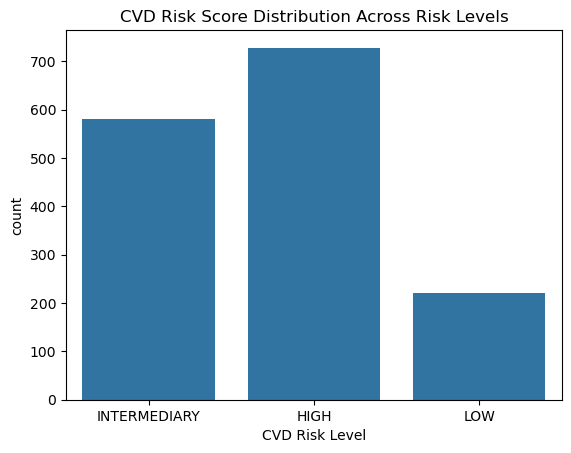

In [14]:
plt.title("CVD Risk Score Distribution Across Risk Levels")
sns.countplot(x="CVD Risk Level", data=df)

In [15]:
df["CVD Risk Level"].value_counts()

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

#### 5.3 Demographic Analysis

Text(0, 0.5, 'Count')

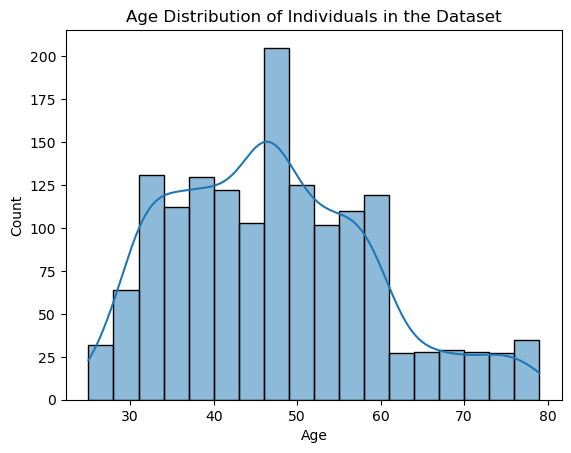

In [16]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution of Individuals in the Dataset")
plt.xlabel("Age")
plt.ylabel("Count")

The histogram shows that most individuals in the dataset are concentrated in the middle-age range (approximately 35–60 years old), with fewer individuals in the younger and older age groups.

<Axes: xlabel='CVD Risk Level', ylabel='Age'>

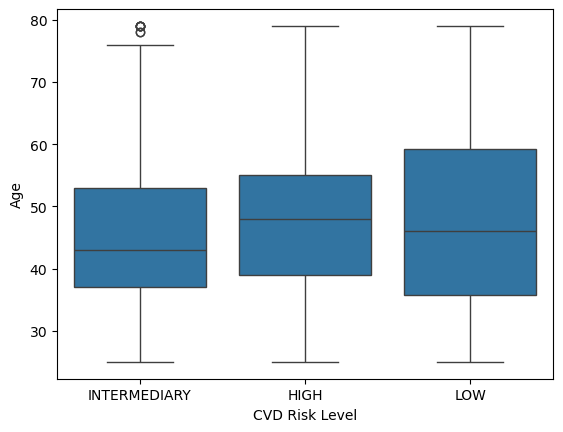

In [17]:


sns.boxplot(x="CVD Risk Level", y="Age", data=df)

The graph shows that individuals in the High CVD Risk group tend to have a slightly higher median age compared to the Intermediary and Low risk groups, suggesting that increasing age may be associated with greater cardiovascular risk.

In [18]:
df["Sex"].value_counts()

Sex
F    773
M    756
Name: count, dtype: int64

There are more females than males in the dataset

<Axes: title={'center': 'Gender Distribution Across CVD Risk Levels'}, xlabel='Sex', ylabel='count'>

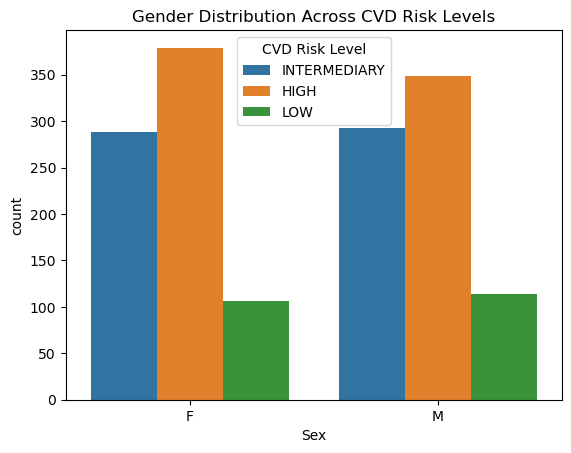

In [19]:
plt.title("Gender Distribution Across CVD Risk Levels")
sns.countplot(x="Sex", hue="CVD Risk Level", data=df)

The graph shows that females are slightly more represented than males in the dataset, which explains the higher counts observed across most CVD risk levels rather than indicating a clear gender-based difference in cardiovascular risk.

#### 5.5 Categorical Distributions

Sex
F    773
M    756
Name: count, dtype: int64
---
Smoking Status
Y    789
N    740
Name: count, dtype: int64
---
Diabetes Status
Y    777
N    752
Name: count, dtype: int64
---
Physical Activity Level
High        521
Moderate    512
Low         496
Name: count, dtype: int64
---
Family History of CVD
N    780
Y    749
Name: count, dtype: int64
---
CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64
---


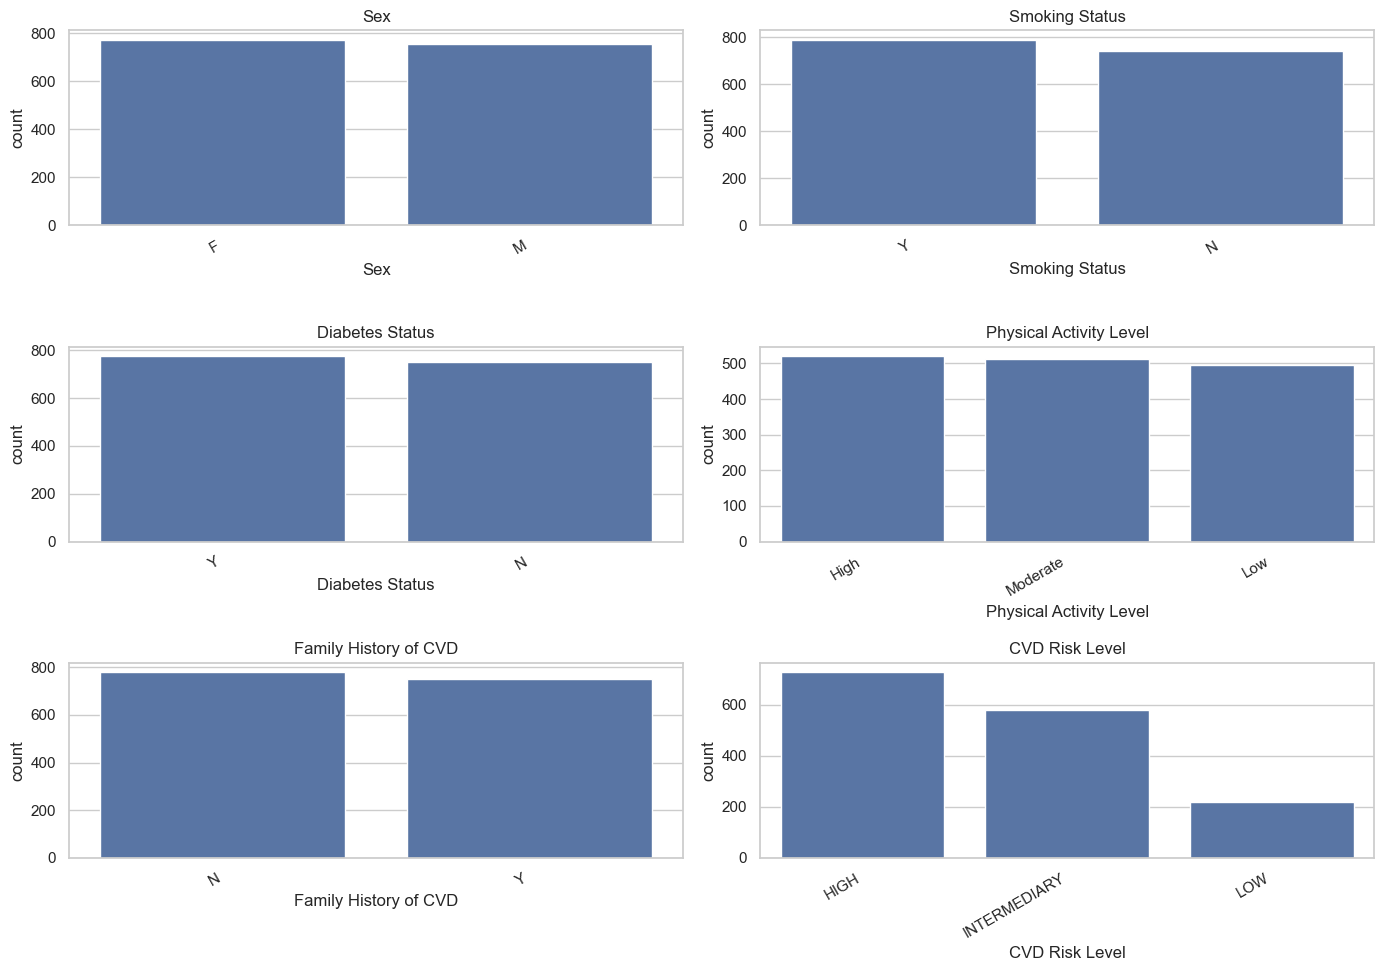

In [44]:
cat_plot_cols = ['Sex','Smoking Status','Diabetes Status','Physical Activity Level','Blood Pressure Category','Family History of CVD','CVD Risk Level']
cat_plot_cols_present = [c for c in cat_plot_cols if c in df.columns]

# Print counts for key categoricals
for col_name in cat_plot_cols_present:
    print(df[col_name].value_counts(dropna=False))
    print('---')

plt.figure(figsize=(14, 12))
for idx, col_name in enumerate(cat_plot_cols_present, start=1):
    plt.subplot(4, 2, idx)
    order_vals = df[col_name].value_counts().index.tolist()
    sns.countplot(data=df, x=col_name, order=order_vals)
    plt.title(col_name)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### 5.5 Body Measurement Analysis

Text(0, 0.5, 'Count')

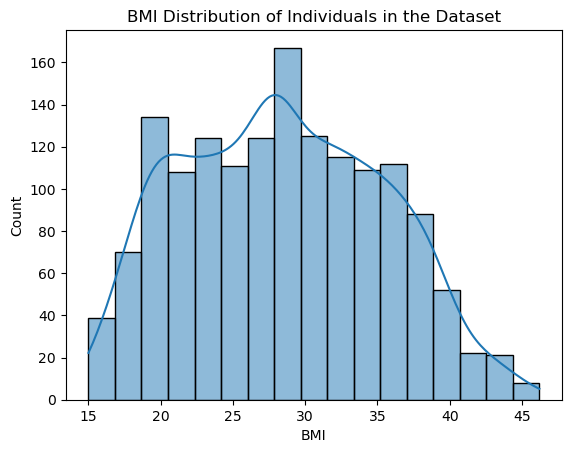

In [20]:
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution of Individuals in the Dataset")
plt.xlabel("BMI")
plt.ylabel("Count")

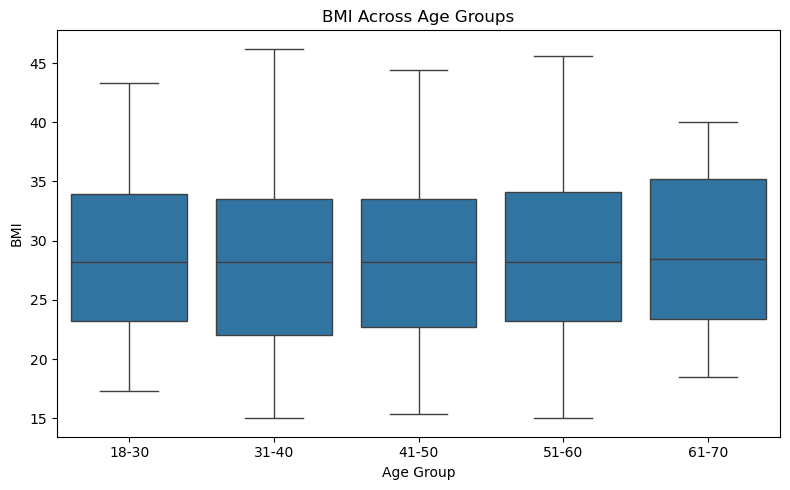

In [21]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Age Group",
    y="BMI",
    data=df
)

plt.title("BMI Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_19396\1412023386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_trend = df.groupby("Age Group")["Weight (kg)"].mean().reset_index()


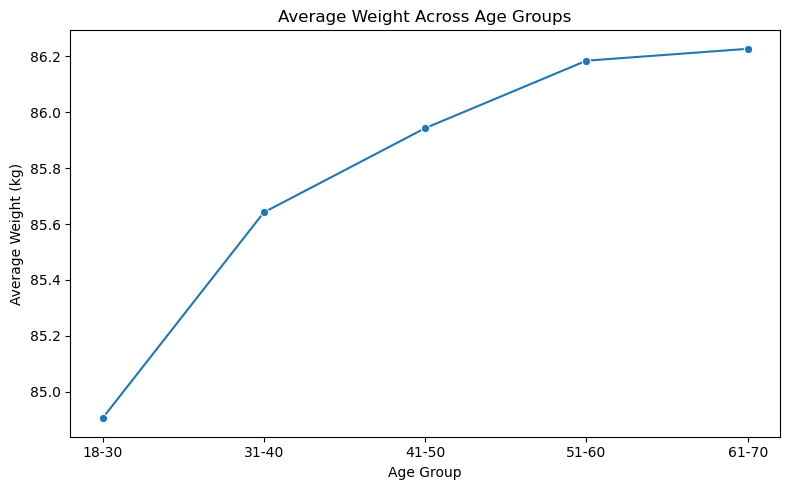

In [22]:
weight_trend = df.groupby("Age Group")["Weight (kg)"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Age Group",
    y="Weight (kg)",
    data=weight_trend,
    marker="o"
)

plt.title("Average Weight Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Average Weight (kg)")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'BMI Across CVD Risk Levels')

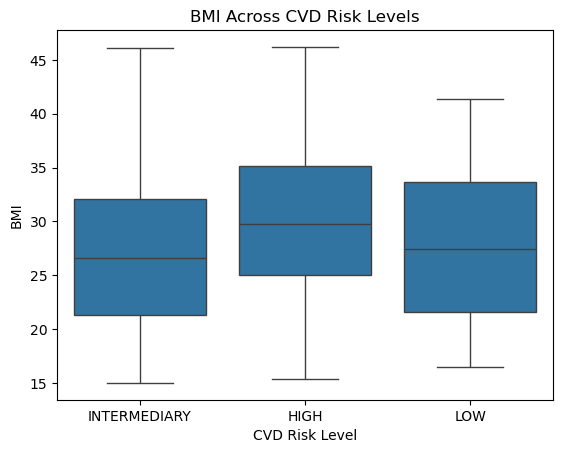

In [23]:
sns.boxplot(x="CVD Risk Level", y="BMI", data=df)
plt.title("BMI Across CVD Risk Levels")

Text(0.5, 1.0, 'BMI vs Waist-to-Height Ratio by CVD Risk Level')

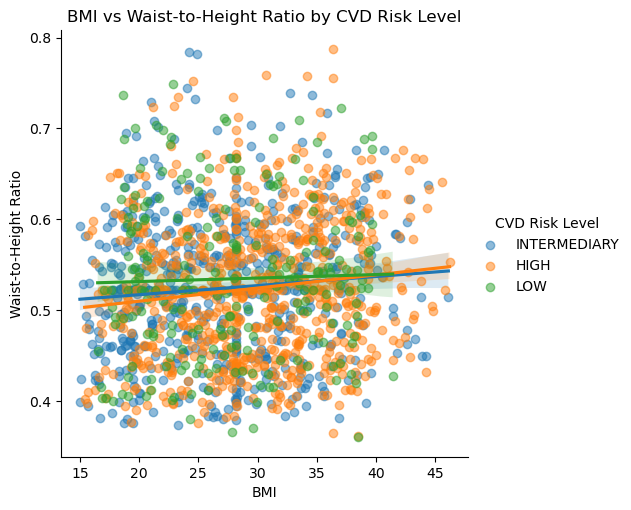

In [24]:
sns.lmplot(
    x="BMI",
    y="Waist-to-Height Ratio",
    hue="CVD Risk Level",
    data=df,
    scatter_kws={"alpha":0.5}
)
plt.title("BMI vs Waist-to-Height Ratio by CVD Risk Level")

Text(0.5, 1.0, 'Waist-to-Height Ratio Across CVD Risk Levels')

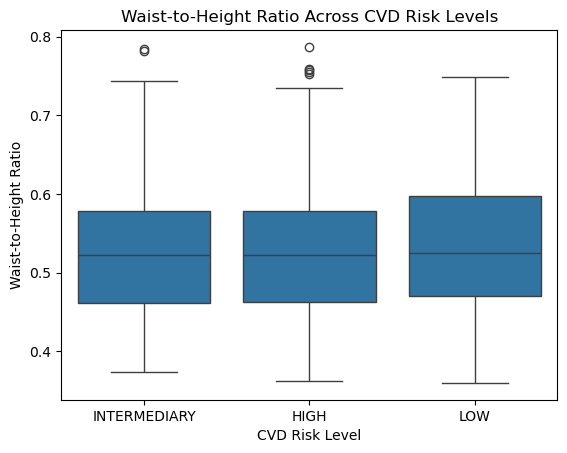

In [25]:
sns.boxplot(x="CVD Risk Level", y="Waist-to-Height Ratio", data=df)
plt.title("Waist-to-Height Ratio Across CVD Risk Levels")

#### 5.6 Lifestyle and Health Factors

C:\Users\USER\AppData\Local\Temp\ipykernel_19396\3942097939.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Physical Activity Level"]


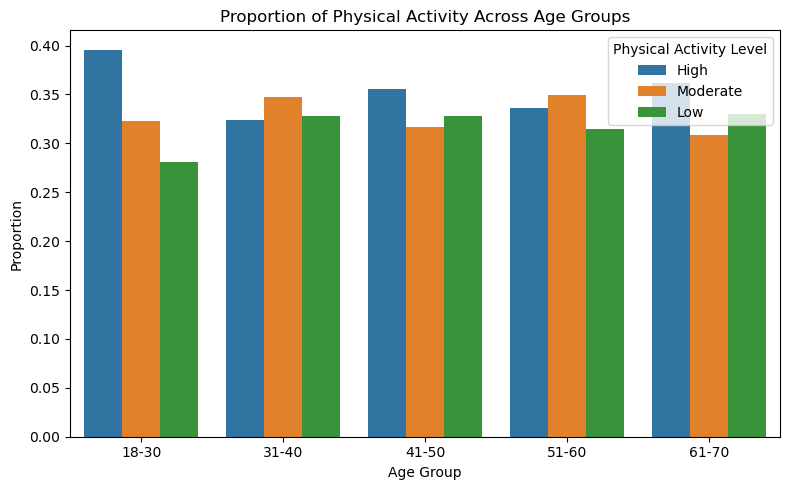

In [26]:
activity_prop = (
    df.groupby("Age Group")["Physical Activity Level"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Age Group",
    y="Proportion",
    hue="Physical Activity Level",
    data=activity_prop
)

plt.title("Proportion of Physical Activity Across Age Groups")
plt.tight_layout()
plt.show()

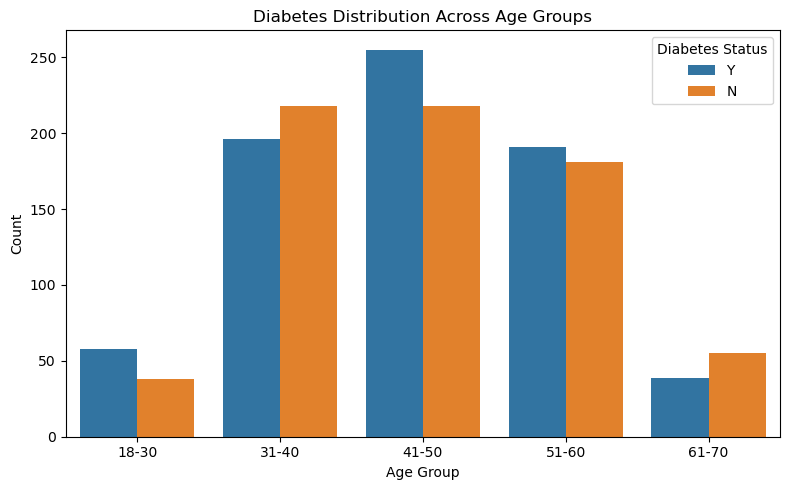

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Age Group",
    hue="Diabetes Status", 
    data=df
)

plt.title("Diabetes Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Proportion')

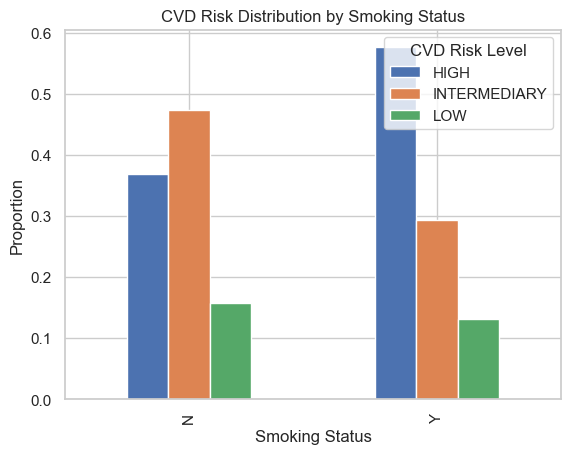

In [41]:
smoking_risk = pd.crosstab(df["Smoking Status"], df["CVD Risk Level"], normalize="index")

smoking_risk.plot(kind="bar", stacked=False)
plt.title("CVD Risk Distribution by Smoking Status")
plt.ylabel("Proportion")

To generalize this analysis across all categorical variables, the following unified approach was used:

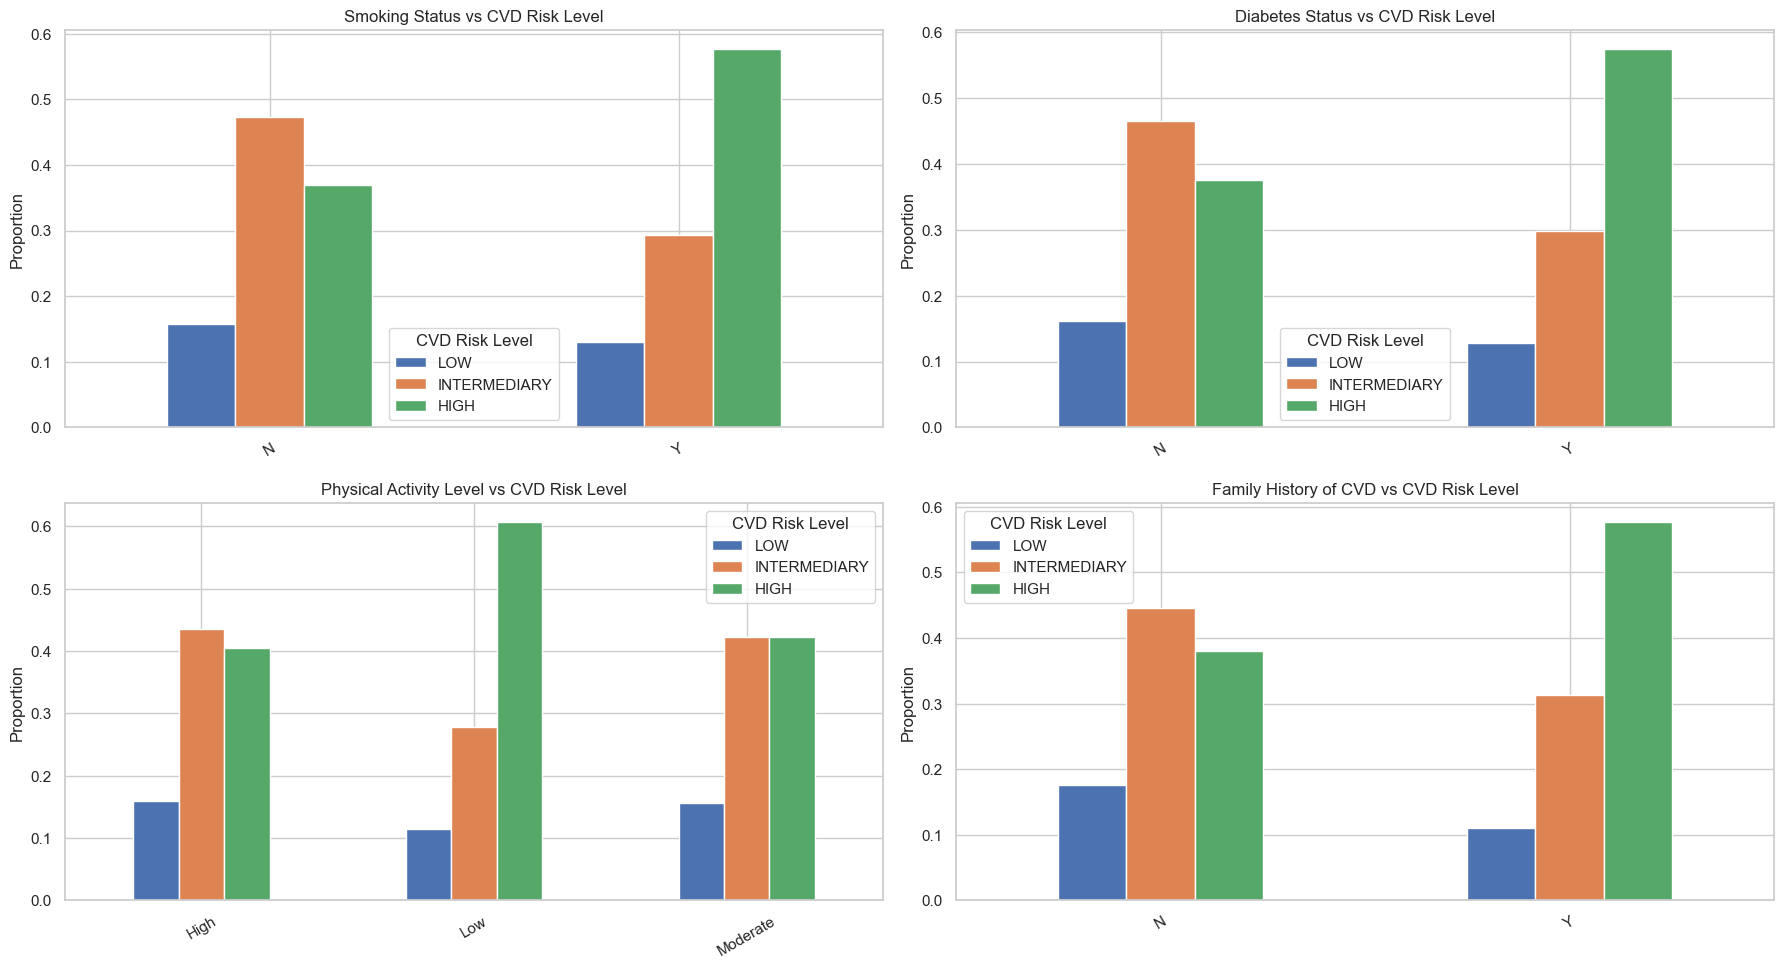


Smoking Status
CVD Risk Level   HIGH  INTERMEDIARY    LOW
Smoking Status                            
N               0.369         0.473  0.158
Y               0.577         0.293  0.131

Diabetes Status
CVD Risk Level    HIGH  INTERMEDIARY    LOW
Diabetes Status                            
N                0.375         0.464  0.161
Y                0.574         0.299  0.127

Physical Activity Level
CVD Risk Level            HIGH  INTERMEDIARY    LOW
Physical Activity Level                            
High                     0.405         0.436  0.159
Low                      0.607         0.278  0.115
Moderate                 0.422         0.422  0.156

Family History of CVD
CVD Risk Level          HIGH  INTERMEDIARY    LOW
Family History of CVD                            
N                      0.379         0.445  0.176
Y                      0.577         0.312  0.111


In [42]:
# Order of risk levels for consistent plotting
risk_order = ['LOW', 'INTERMEDIARY', 'HIGH']

# Select categorical variables
cat_vars = [
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD'
]

# Keep only columns that exist in dataset
cat_vars_present = [col for col in cat_vars if col in df.columns]

# Plot proportions
plt.figure(figsize=(18, 14))

for i, col in enumerate(cat_vars_present, 1):
    plt.subplot(3, 2, i)
    
    # Create normalized crosstab (proportions)
    ctab = pd.crosstab(df[col], df['CVD Risk Level'], normalize='index')
    ctab = ctab.reindex(columns=risk_order)
    
    ctab.plot(kind='bar', stacked=False, ax=plt.gca())
    
    plt.title(f'{col} vs CVD Risk Level')
    plt.xlabel('')
    plt.ylabel('Proportion')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Print tables for reference
for col in cat_vars_present:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df['CVD Risk Level'], normalize='index').round(3))

#### 5.7 Clinical indicators

#### Blood Pressure

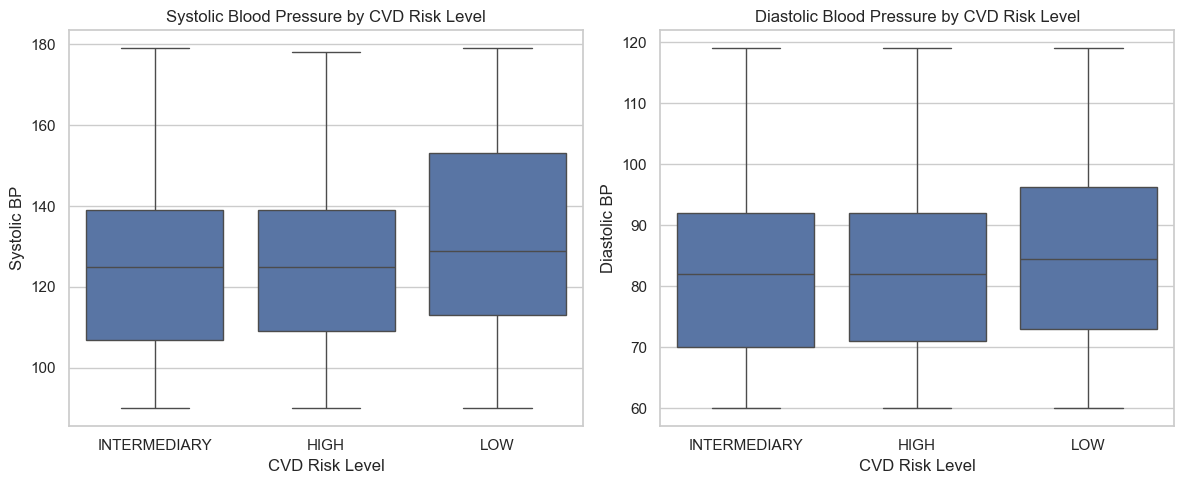

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Systolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Systolic BP",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Systolic Blood Pressure by CVD Risk Level")

# Diastolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Diastolic BP",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Diastolic Blood Pressure by CVD Risk Level")

plt.tight_layout()
plt.show()

#### Cholesterol Profile

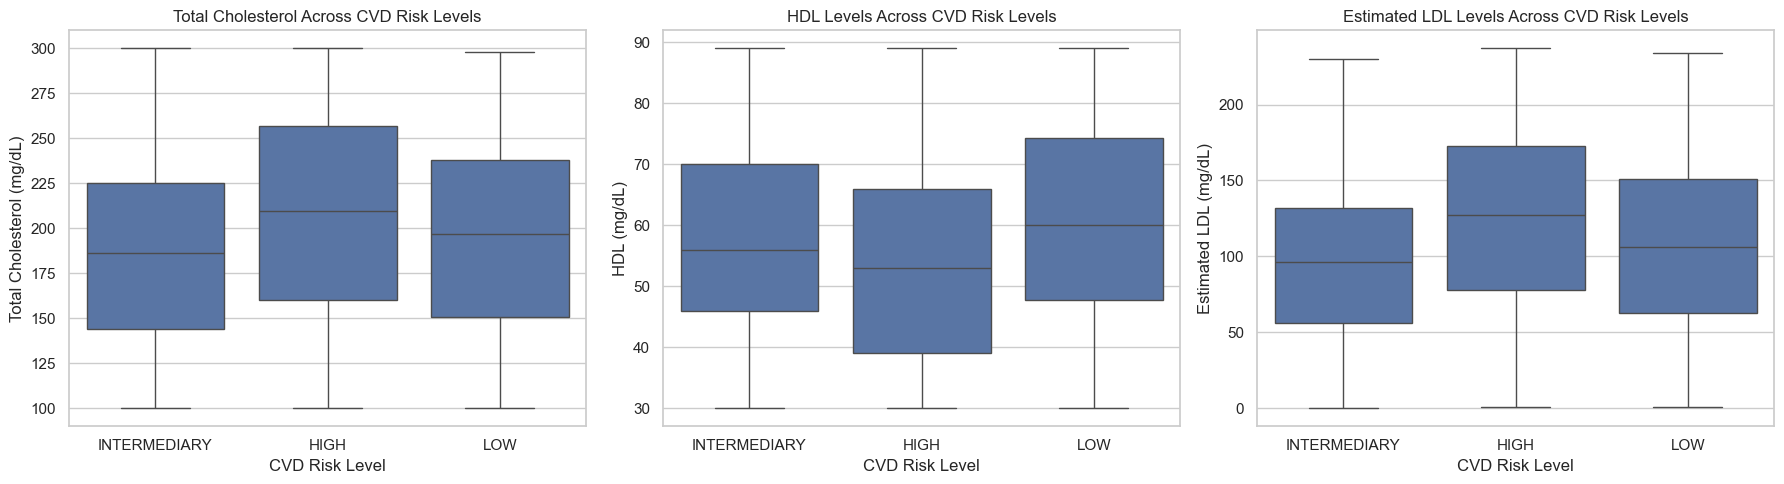

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x="CVD Risk Level", y="Total Cholesterol (mg/dL)", data=df, ax=axes[0])
axes[0].set_title("Total Cholesterol Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="HDL (mg/dL)", data=df, ax=axes[1])
axes[1].set_title("HDL Levels Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="Estimated LDL (mg/dL)", data=df, ax=axes[2])
axes[2].set_title("Estimated LDL Levels Across CVD Risk Levels")

plt.tight_layout()
plt.show()

#### Blood Sugar

Text(0, 0.5, 'Fasting Blood Sugar (mg/dL)')

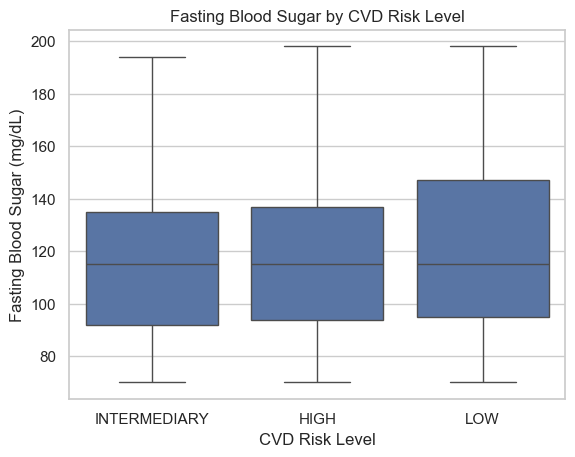

In [32]:
sns.boxplot(
    x="CVD Risk Level",
    y="Fasting Blood Sugar (mg/dL)",
    data=df
)

plt.title("Fasting Blood Sugar by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Fasting Blood Sugar (mg/dL)")

#### 5.8 Correlation Heatmap of Numerical Features

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

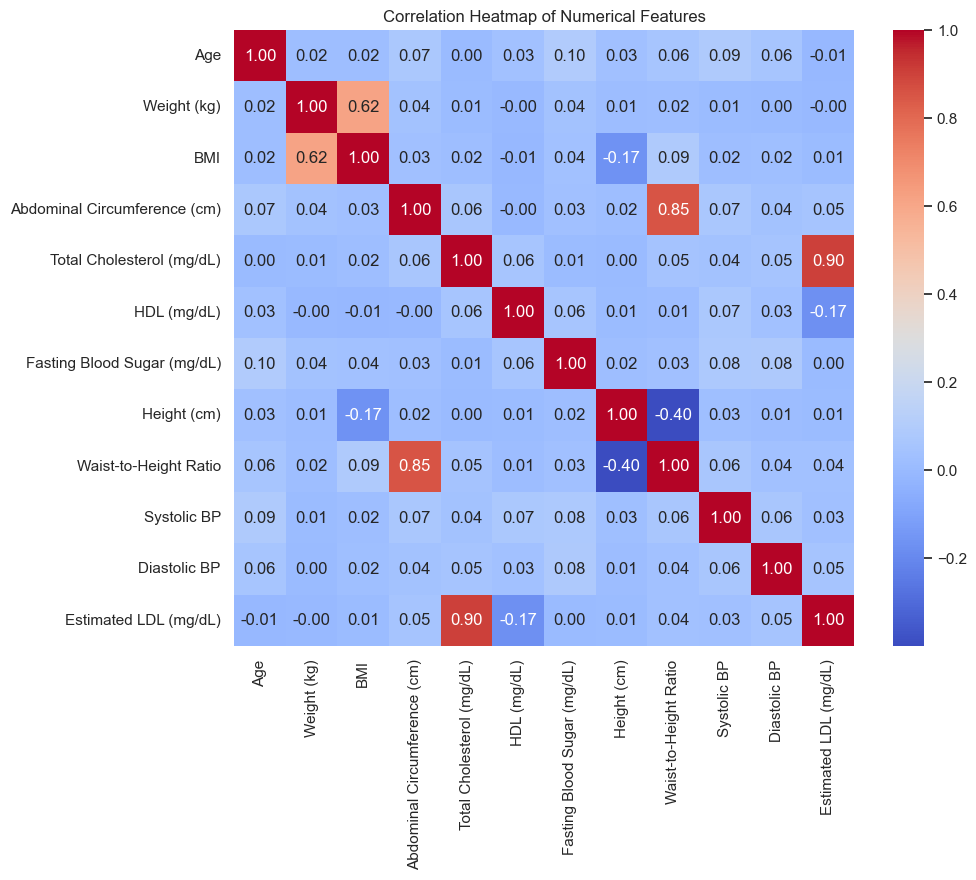

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")